In [71]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns 

import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import jax.random as jr
import blackjax

In [72]:
rng_key = jr.key(0);
prior_cov_matrix = jnp.array([[5.0, 0],
                       [0, 1.0]])
measurement_error_bar = 0.1;
# Measurement: e^x + e^y = 1 +\- 0.1
def log_density_fcn(x, y):
    log_P_data_given_signal = -0.5*((jnp.exp(x) + jnp.exp(y) - 1)/measurement_error_bar)**2;
    v = jnp.array([x, y]);
    log_P_signal =  -0.5*v.T @ jnp.linalg.inv(prior_cov_matrix) @ v; 
    return log_P_data_given_signal + log_P_signal;

logdensity = lambda x: log_density_fcn(**x)

inv_mass_matrix = prior_cov_matrix;
num_integration_steps = 60
step_size = 1e-3

hmc = blackjax.hmc(logdensity, step_size, inv_mass_matrix, num_integration_steps)

initial_position = {"x": 0.0, "y": 0.0}
initial_state = hmc.init(initial_position)
initial_state

HMCState(position={'x': 0.0, 'y': 0.0}, logdensity=Array(-50., dtype=float32), logdensity_grad={'x': Array(-100., dtype=float32, weak_type=True), 'y': Array(-100., dtype=float32, weak_type=True)})

In [73]:
hmc_kernel = jax.jit(hmc.step)

def inference_loop(rng_key, kernel, initial_state, num_samples):
    @jax.jit
    def one_step(state, rng_key):
        state, _ = kernel(rng_key, state)
        return state, state

    keys = jax.random.split(rng_key, num_samples)
    _, states = jax.lax.scan(one_step, initial_state, keys)

    return states



rng_key, sample_key = jax.random.split(rng_key)
states = inference_loop(sample_key, hmc_kernel, initial_state, 10_000)

mcmc_samples = states.position

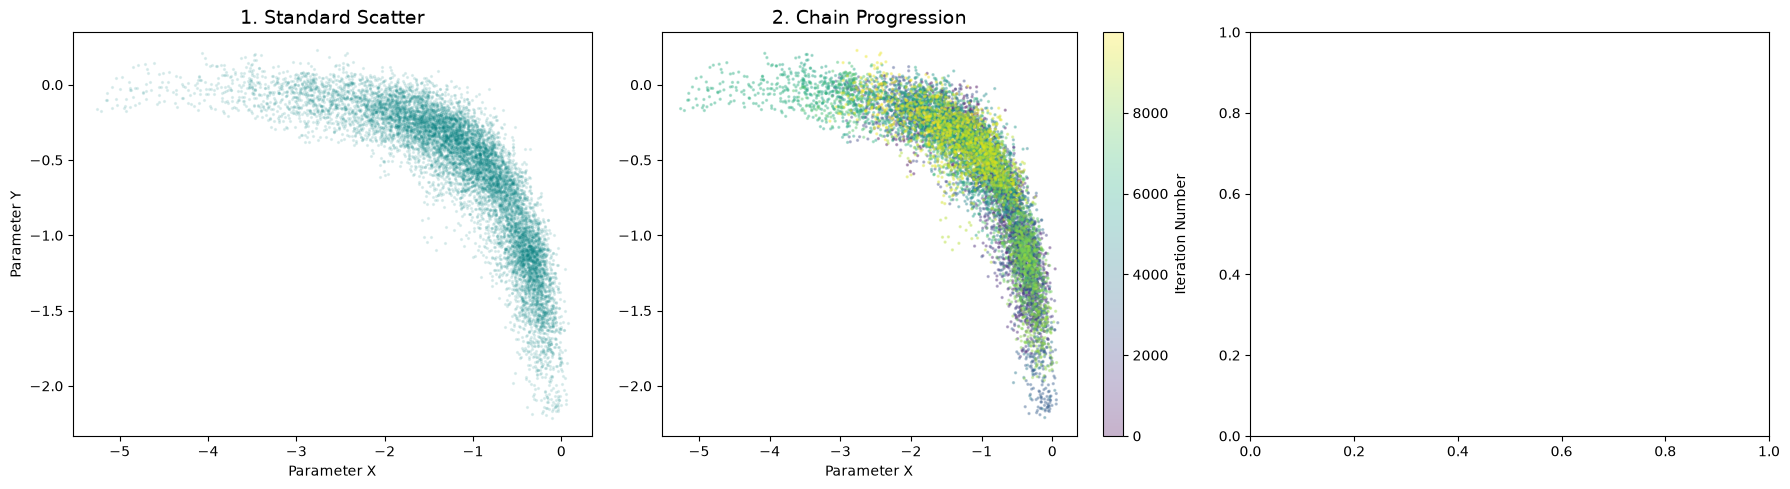

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(mcmc_samples["x"], mcmc_samples["y"], alpha=0.1, s=2, color='teal')
axes[0].set_title("1. Standard Scatter", fontsize=14)
axes[0].set_xlabel("Parameter X")
axes[0].set_ylabel("Parameter Y")

# ---------------------------------------------------------
# SUBPLOT 2: The Chain Progression (axes[1])
# ---------------------------------------------------------
scatter2 = axes[1].scatter(mcmc_samples["x"], mcmc_samples["y"], 
                           c=iterations, cmap='viridis', alpha=0.3, s=2)
axes[1].set_title("2. Chain Progression", fontsize=14)
axes[1].set_xlabel("Parameter X")
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[1], label="Iteration Number") 

# 3. Final Polish and Display
plt.tight_layout() # Prevents overlapping text/labels between the plots
plt.show()